In [6]:
#1. IMPORT LIBRARIES

from sklearn import datasets
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
logistic = LogisticRegression

In [7]:
#2. LOAD DATA

df = pd.read_csv('Titanic-Dataset.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
#3. DATA CLEANING

# Remove missing values
df = df.dropna(axis='rows').reset_index(drop=True)

# Clean text and encode Sex
df['Sex'] = df['Sex'].str.lower().str.strip()
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
1,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
2,7,0,1,"McCarthy, Mr. Timothy J",1,54.0,0,0,17463,51.8625,E46,S
3,11,1,3,"Sandstrom, Miss. Marguerite Rut",0,4.0,1,1,PP 9549,16.7000,G6,S
4,12,1,1,"Bonnell, Miss. Elizabeth",0,58.0,0,0,113783,26.5500,C103,S
...,...,...,...,...,...,...,...,...,...,...,...,...
178,872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",0,47.0,1,1,11751,52.5542,D35,S
179,873,0,1,"Carlsson, Mr. Frans Olof",1,33.0,0,0,695,5.0000,B51 B53 B55,S
180,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",0,56.0,0,1,11767,83.1583,C50,C
181,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,B42,S


In [42]:
print(df['Age'].isna().sum())

0


In [9]:
#4. SELECT FEATURES

X = df[['Pclass', 'Age', 'Sex']]
Y = df['Survived']

In [ ]:
# or
Y = df.Survived

In [33]:
#5. TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [34]:
# 6. TRAIN MODEL

#Defining the model:
model = LogisticRegression()

#Fit the model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
model.coef_

array([[-0.61742833, -0.02643476, -2.36186273]])

In [22]:
model.intercept_

array([4.002245])

In [23]:
X.head()

,Pclass,Age,Sex
0,1,38.0,0
1,1,35.0,0
2,1,54.0,1
3,3,4.0,0
4,1,58.0,0


In [ ]:
Y = 4.002 - 0.617(Pclass) - 2.37(Sex) - 0.036(Age)

In [16]:
import math as mt

Pclass = 1
Age = 54
Sex = 1

mt.e**(4.002 - 0.617*(Pclass) - 2.37*(Sex) - 0.036*(Age))


0.3949484614246032

In [35]:
#7. PREDICT

y_pred = model.predict(X_test)

In [36]:
#8. EVALUATION

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7297297297297297


In [ ]:
#Baseline Model Performance:
# The initial model achieved an accuracy of approximately 73.0%. 
# This serves as a baseline performance, indicating that while the model has captured some basic trends in the data, 
# it fails to account for more complex, non-linear relationships that influence passenger survival on the Titanic.

In [37]:
#Improve accuracy using decission tree 

from sklearn.model_selection import train_test_split
from sklearn import tree

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)

# Model
tree_model = tree.DecisionTreeClassifier()

# Train model
tree_model.fit(X_train, y_train)

# Errors
train_error = 1 - tree_model.score(X_train, y_train)
test_error = 1 - tree_model.score(X_test, y_test)

# Print results
print(f"Training error: {train_error:.5f}")
print(f"Test error: {test_error:.5f}")



Training error: 0.06164
Test error: 0.18919


In [38]:
y_pred = tree_model.predict(X_test)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8108108108108109


In [ ]:
# Model Performance Analysis:
#The Decision Tree model achieved an accuracy of approximately 81.1%. 
#This result suggests that the model has effectively identified key features—such as gender, ticket class, and fare—that significantly influenced survival rates on the Titanic.
#Compared to the Logistic Regression model, the Decision Tree demonstrates improved predictive performance by capturing non-linear relationships within the data.

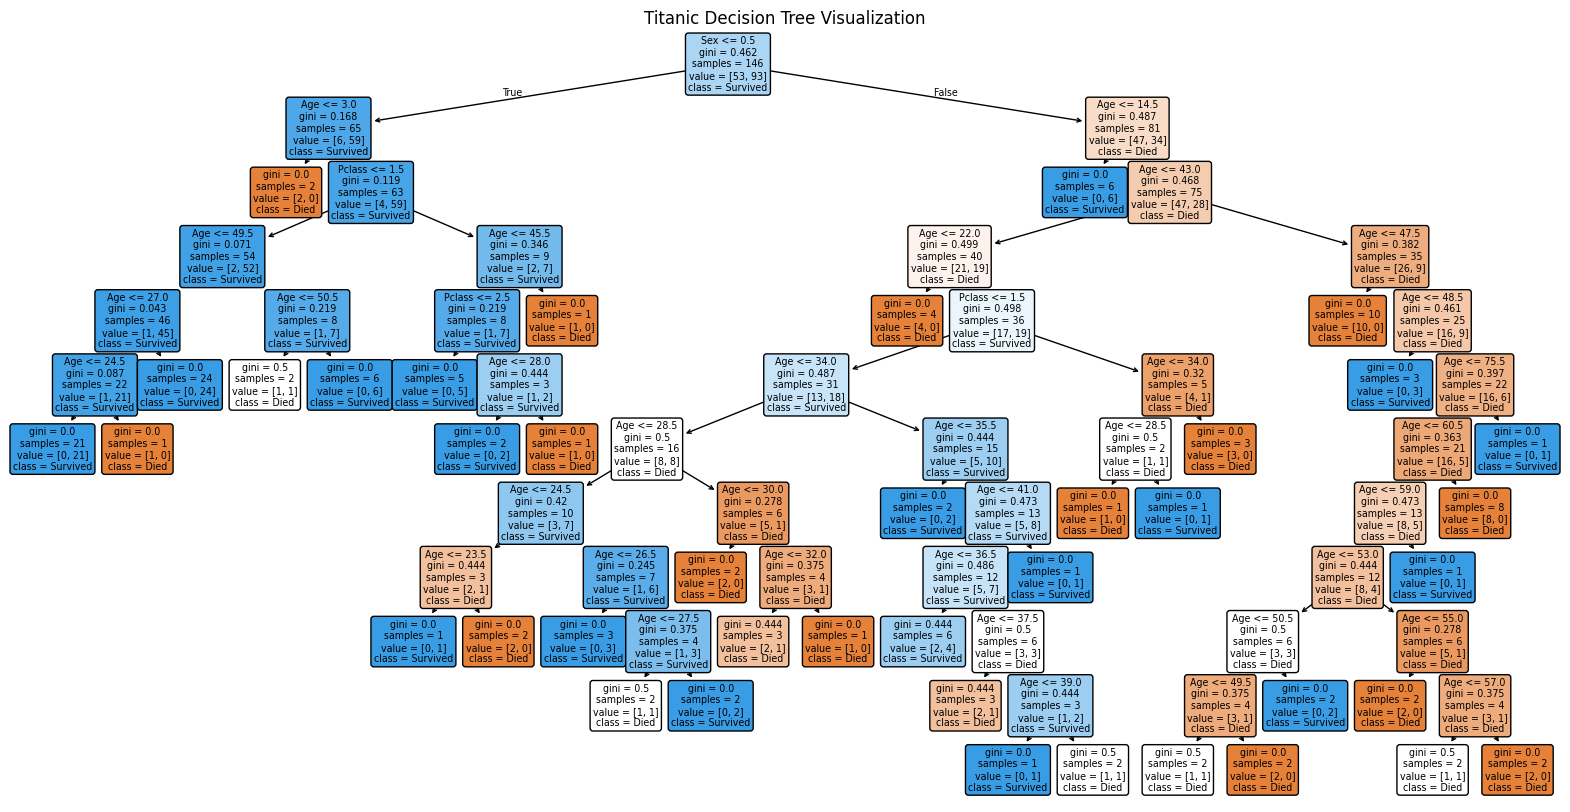

In [40]:
# --- Visualizing the Decision Tree ---
# We visualize the decision tree to interpret the rules the model has learned.
# This provides transparency, showing how passenger features lead to survival predictions.

import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(tree_model, 
               filled=True, 
               feature_names=X.columns, 
               class_names=['Died', 'Survived'], 
               rounded=True)
plt.title("Titanic Decision Tree Visualization")
plt.show()

In [ ]:
#Interpretation:
#The decision tree visualization reveals that 'Sex' is the primary factor in predicting passenger survival.
#The tree further splits based on 'Age' and 'Pclass' (Passenger Class). The branches colored in blue represent the 'Survived' class, while orange represents 'Died'.
#The depth of the tree suggests that the model has learned complex rules from the dataset to achieve an accuracy of ~81%.